# RA Risk Model — Gradient Boosted Trees on the Simulated Cohort

This notebook is a pipeline rehearsal on your own simulated data (`Data/labels_drift_0.0.csv`, the per-patient export from `Algorithm.java`'s `exportPatientLabels`), before real patient data arrives. It:

1. Trains an XGBoost classifier to predict RA status from `age, bmi, smoker, alleleCount, sex`.
2. Backtests it on a held-out split.
3. Uses SHAP to check whether the model recovers the individual risk factors' known effect sizes (the literature-derived ORs baked into `getRisk()`).
4. Uses SHAP **interaction values** to test the one genuinely uncertain structural assumption: does an age×BMI interaction emerge from the data the way the simulation's drift mechanism assumes, even though no such interaction is told to the model in advance?

**A framing note before you read the results:** this cohort's outcome was generated by the exact mechanism in `getRisk()` — a known, fairly clean function of these five features. A model recovering that relationship well is a **sanity check that the pipeline and the model are working**, not evidence the same model will perform equally well on noisy real-world data. Treat everything below as pipeline validation, not as the paper's actual result.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, classification_report
import xgboost as xgb
import shap

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RANDOM_STATE = 0

C:\Users\thats\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

`Data/labels_drift_0.0.csv` is the per-patient export: each of the 10M baseline patients, independently advanced 25 years (no drift, no population replacement-on-death — see the comment on `exportPatientLabels` in `Algorithm.java` for why), with `hasRA`, `yearsToOnset`, and `diedFirst` recorded.

**Simplification flag:** `diedFirst` patients who died before any RA onset are treated here as plain negatives (`hasRA=0`). That's a simplification of the true structure (they're censored, not confirmed negative) — the correct treatment is the survival/Poisson framing from the lecture notes (§4), not plain binary classification. Fine for a pipeline rehearsal; worth revisiting once this moves to real data.

In [2]:
df = pd.read_csv("Data/labels_drift_0.0.csv")

FEATURES = ["age", "bmi", "smoker", "alleleCount", "sex"]
TARGET = "hasRA"

print(f"rows: {len(df):,}")
print(f"RA prevalence: {df[TARGET].mean()*100:.3f}%")
print(f"diedFirst: {df['diedFirst'].mean()*100:.2f}%")
df.head()

rows: 10,000,000
RA prevalence: 0.529%
diedFirst: 40.83%


,id,age,bmi,smoker,alleleCount,sex,hasRA,yearsToOnset,diedFirst
0,1,17,21.1910,0,0,0,0,-1,0
1,2,43,25.9952,0,0,1,0,-1,0
2,3,69,32.0789,0,1,0,0,-1,1
3,4,19,23.8796,0,0,0,0,-1,0
4,5,41,25.3656,0,0,1,0,-1,1


## 2. Backtest split

Standard train/test split (§ backtesting from earlier in the conversation): the model only ever sees `X_train`/`y_train` during fitting. Everything reported below comes from predictions on `X_test`, which the model never touched. Stratified on the target since RA is rare (~0.5%) — a plain random split risks an unlucky test fold with too few positive cases to evaluate meaningfully.

In [3]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {len(X_train):,} rows, {y_train.mean()*100:.3f}% RA")
print(f"test:  {len(X_test):,} rows, {y_test.mean()*100:.3f}% RA")

train: 8,000,000 rows, 0.529% RA
test:  2,000,000 rows, 0.529% RA


## 3. Train

Same mechanics as the lecture notes' §3–§5: shallow trees (`max_depth`), shrinkage (`learning_rate`), and early stopping on a validation split so the model stops adding trees once it's no longer improving out-of-sample — the regularization from §7 that keeps this from overfitting, made concrete.

`scale_pos_weight` upweights the rare positive class during training — without it, a classifier facing ~0.5% prevalence can get away with predicting "no RA" for everyone and still look accurate, which is useless. This *doesn't* change what the model can learn, just how heavily it's penalized for missing a true case during training.

In [4]:
# Carve a validation slice out of the training set for early stopping —
# X_test stays untouched until final evaluation, below.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
)

scale_pos_weight = (y_fit == 0).sum() / (y_fit == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

print(f"stopped at {model.best_iteration} trees (of 500 allowed)")

stopped at 178 trees (of 500 allowed)


## 4. Backtest: evaluate on the held-out test set

`X_test`/`y_test` have not been touched by training or by early stopping — this is the honest "how would it do on a new patient" check. Reporting both ROC-AUC and PR-AUC (average precision): with prevalence this low, ROC-AUC can look deceptively good, since it doesn't reflect ranking performance among the true positives — PR-AUC is the more informative number for a rare-outcome problem.

ROC-AUC: 0.7786
PR-AUC:  0.0302  (no-skill baseline at this prevalence: 0.0053)


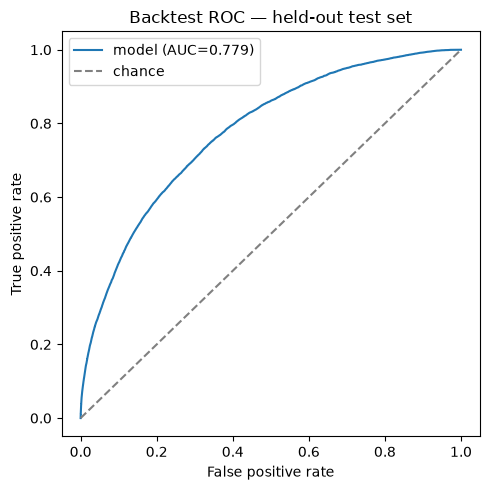

In [5]:
test_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
baseline_pr = y_test.mean()  # PR-AUC of a random/no-skill classifier at this prevalence

print(f"ROC-AUC: {auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}  (no-skill baseline at this prevalence: {baseline_pr:.4f})")

fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"model (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Backtest ROC — held-out test set")
plt.legend()
plt.tight_layout()
plt.show()

## 5. SHAP: does the model recover the known risk factors?

Since this cohort's outcome was generated by `getRisk()` with known odds ratios (allele count up to 5.5×, smoking 2.5×, sex 2.5×, an age-dependent baseline, and an age-attenuated BMI effect), a model trained blind to that formula should — if the pipeline is working — independently rediscover roughly that same ranking and direction of effects. This is the sanity check the framing note at the top flagged.

SHAP values are computed on a random subsample of the test set (10,000 rows) — exact on trees, but still costly to compute per-row at full scale, and unnecessary for a summary plot.

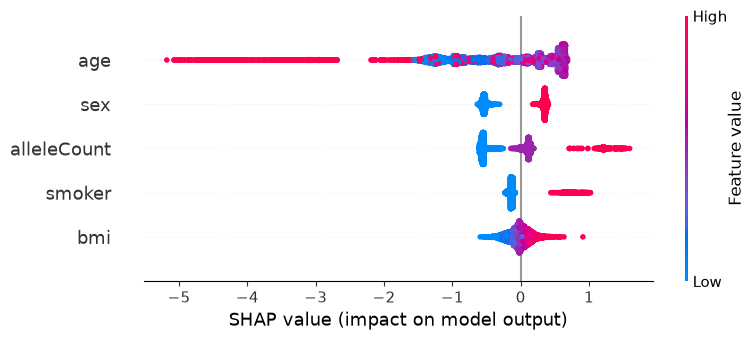

In [6]:
shap_sample = X_test.sample(10_000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model)
shap_values = explainer(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.show()

## 6. SHAP interaction values: the age×BMI hypothesis

This is the actual test, not just a sanity check. `getRisk()` makes BMI's effect *age-dependent* (`b_eff = 1.1 + 0.4·exp(-0.065·max(age-15, 0))`, i.e. BMI matters more in younger patients and that effect decays with age) — that structural assumption, not the individual ORs, is your paper's hypothesis. The model below is never told this age-BMI relationship exists; it only ever sees `age` and `bmi` as two independent columns. If it independently reconstructs an interaction with the same shape, that's real (if circular, on simulated data) support for the mechanism — and the template for the exact same check once real data replaces this cohort.

Interaction values are `O(rows × features²)`, meaningfully more expensive than plain SHAP values — subsampled further (2,000 rows) to stay fast.

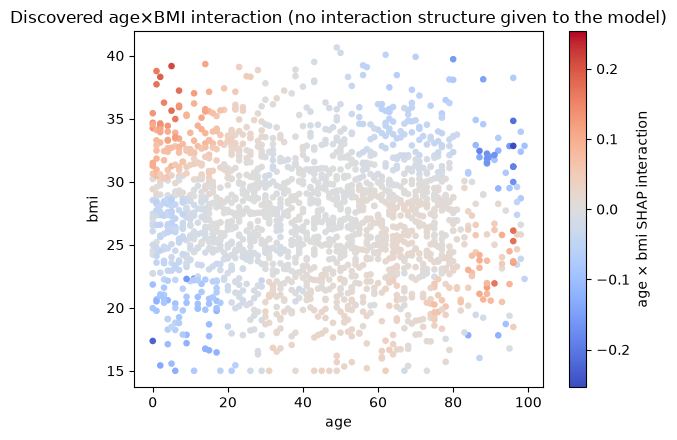

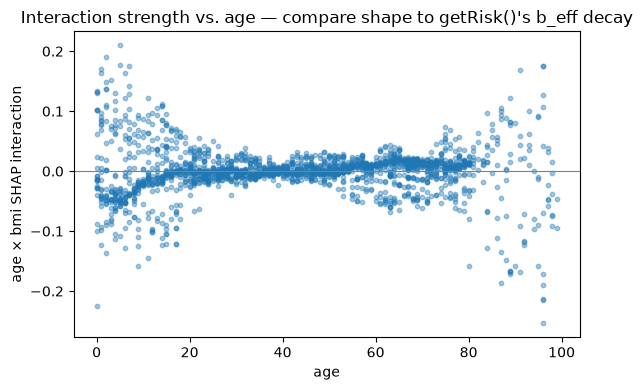

In [7]:
interaction_sample = X_test.sample(2_000, random_state=RANDOM_STATE)

interaction_values = explainer.shap_interaction_values(interaction_sample)  # (rows, features, features)

age_i = FEATURES.index("age")
bmi_i = FEATURES.index("bmi")

# The age<->bmi interaction term specifically, for every sampled patient
age_bmi_interaction = interaction_values[:, age_i, bmi_i]

plt.figure(figsize=(6, 4.5))
sc = plt.scatter(
    interaction_sample["age"], interaction_sample["bmi"],
    c=age_bmi_interaction, cmap="coolwarm", s=14,
    vmin=-np.abs(age_bmi_interaction).max(), vmax=np.abs(age_bmi_interaction).max(),
)
plt.colorbar(sc, label="age × bmi SHAP interaction")
plt.xlabel("age")
plt.ylabel("bmi")
plt.title("Discovered age×BMI interaction (no interaction structure given to the model)")
plt.tight_layout()
plt.show()

# Same information, collapsed to one dimension: does |interaction strength|
# fall off with age the way b_eff's exp(-0.065 * age) decay assumes?
order = np.argsort(interaction_sample["age"].values)
plt.figure(figsize=(6, 4))
plt.scatter(interaction_sample["age"].values[order], age_bmi_interaction[order], s=10, alpha=0.4)
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("age")
plt.ylabel("age × bmi SHAP interaction")
plt.title("Interaction strength vs. age — compare shape to getRisk()'s b_eff decay")
plt.tight_layout()
plt.show()

## 7. Where this goes from here

- **If the backtest AUC/PR-AUC look strong and §5's SHAP ranking matches the built-in ORs**, that confirms the pipeline itself is sound — train/test split, class-imbalance handling, model fitting, and SHAP are all wired correctly. It does *not* mean the model will perform this well on real data (see the framing note in §0).
- **§6 is the piece to revisit once real data arrives**, unchanged in structure: same `shap_interaction_values` call, same age×BMI extraction, just pointed at a model trained on real patients instead of this simulated cohort. Agreement between what it finds there and what's plotted above would be genuine empirical support for the drift mechanism's age-dependence — not circular, since the real model is never told the hypothesis either.
- **Other drift scenarios**: `Data/labels_drift_0.0.csv` only covers `drift=0.0`. Re-running `exportPatientLabels(..., drift, YEARS, filename)` for the other `BMI_DRIFTS` values would let you compare how this model's *discovered* structure shifts across drift scenarios against the aggregate incidence curves in `Graphs/`.
- **The `diedFirst` simplification** flagged in §1 is the main thing worth fixing before treating any of this as more than a rehearsal — a Poisson/survival framing (lecture §4) would use `yearsToOnset` and `diedFirst` properly instead of collapsing to a single binary label.